In [1]:
import os
import pickle as pickle
import glob
import skimage
import skimage.transform
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import csv
from mpl_toolkits.axes_grid1 import host_subplot

import sys
%matplotlib inline

# Plot the tight-binding model calculation and simulated acoustic kagome band structure

In [2]:
b_sim = []
bands_sim = np.zeros((3, 0))  # Initialize an empty array with 3 rows

with open('../../../data/simulation/kagome_machine_bands_clean.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)

    for row in reader:
        b_sim.append(float(row[0]))
        bands_sim = np.hstack((bands_sim, np.array([[float(row[1])], [float(row[2])], [float(row[3])]])))

b_sim = np.array(b_sim)

In [3]:
# calculate the tight-binding results

L=1

k_res = len(b_sim)
# Define the GKMG sweep in reciprocal space
kx1 = np.linspace(0, 2*np.pi/3/L, int(k_res/(3+np.sqrt(3))*2), endpoint=False)
ky1 = np.linspace(0, 0, int(k_res/(3+np.sqrt(3))*2), endpoint=False)

kx2 = np.linspace(2*np.pi/3/L, 3/2*np.pi/3/L, int(k_res/(3+np.sqrt(3))), endpoint=False)
ky2 = np.linspace(0, np.pi/np.sqrt(3)/2/L, int(k_res/(3+np.sqrt(3))), endpoint=False)

kx3 = np.linspace(3/2*np.pi/3/L, 0, int(np.ceil(k_res/(3+np.sqrt(3))*np.sqrt(3))), endpoint=False)
ky3 = np.linspace(np.pi/np.sqrt(3)/2/L, 0, int(np.ceil(k_res/(3+np.sqrt(3))*np.sqrt(3))), endpoint=False)

kx_sweep = np.concatenate([kx1, kx2, kx3])
ky_sweep = np.concatenate([ky1, ky2, ky3])

bands_TB = np.zeros((3, len(kx_sweep)))  # Placeholder for band energies
t = 1

for i, (kx, ky) in tqdm(enumerate(zip(kx_sweep, ky_sweep))):
    M = -t*np.array([[0, 1+np.exp(-1j*2*kx*L), 1+np.exp(-1j*(kx-np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*2*kx*L), 0, 1+np.exp(1j*(kx+np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*(kx-np.sqrt(3)*ky)*L), 1+np.exp(-1j*(kx+np.sqrt(3)*ky)*L), 0]])

    bands_TB[:,i] = np.linalg.eigvalsh(M)

48it [00:00, 36886.51it/s]


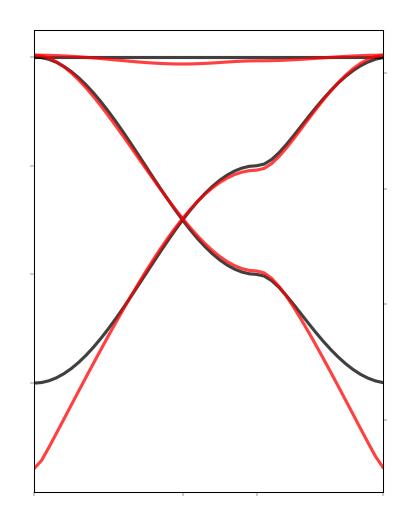

In [18]:
# Set figure size and DPI when creating the figure
fig = plt.figure(figsize=(1.5, 2), dpi=300)
host = host_subplot(111)
par = host.twinx()

host.set_xlim(0, b_sim[-1])
host.set_ylim(-6, 2.5)
par.set_ylim(-0.5, 15.5)

host.set_xticks([0, 1, 1.5 , 2.35], ['', '', '', ''])
host.set_yticks(np.linspace(-4, 2, 4, endpoint=True), ['', '', '', ''])
par.set_yticks(np.linspace(2, 14, 4, endpoint=True), ['', '', '', ''])
host.xaxis.set_tick_params(width=0.1, length = 1)
host.yaxis.set_tick_params(width=0.1, length = 1)
par.yaxis.set_tick_params(width=0.1, length = 1)

for axis in ['top','bottom','left','right']:
    host.spines[axis].set_linewidth(0.25)
    par.spines[axis].set_linewidth(0.25)

for i in range(len(bands_sim)):
    host.plot(b_sim, bands_TB[i], 'k-', linewidth=0.75, alpha=0.75, label = 'Tight-binding' if i == 0 else "")
    par.plot(b_sim, bands_sim[i], 'r-', linewidth=0.75, alpha=0.75, label = 'Acoustic simulation' if i == 0 else "")


plt.savefig("../../../paper_new/intro_fig/kagome_bands_intro.pdf")
plt.show()

In [28]:
m_pt_idx = np.argmin(np.abs(b_sim - 1.5))
print("M point eigenfrequencies:", bands_sim[:,m_pt_idx], "kHz")
t_sound = (bands_sim[1, m_pt_idx] - bands_sim[2, m_pt_idx])/2
print("hopping term in frequency units:", t_sound, "kHz")

M point eigenfrequencies: [14.4267271  10.64112565  7.14657755] kHz
hopping term in frequency units: 1.7472740494999996 kHz
